# Verification

Is Model A's improvement over the baseline statistically significant and robust? And does Model B (+ reviews) add anything beyond Model A?

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from pathlib import Path

RESULTS_DIR = Path('results')
DATA_DIR    = Path('data')

TS_COLS  = ['ts_mean', 'ts_slope', 'ts_curvature', 'ts_range', 'ts_peak_pos']
REV_COLS = ['rev_count', 'rev_mean_rating', 'rev_positive_frac']
TARGET   = 'actual_peak_value'
ALPHAS   = [0.01, 0.1, 1.0, 10.0, 100.0]
N_PERM   = 1000
N_BOOT   = 500

def mae(actual, predicted):
    return float(np.mean(np.abs(np.array(actual, dtype=float) - np.array(predicted, dtype=float))))

def make_pipe(num_cols):
    ct = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['style']),
        ('sc',  StandardScaler(), num_cols),
    ])
    return Pipeline([('ct', ct), ('ridge', RidgeCV(alphas=ALPHAS))])

rng = np.random.default_rng(42)

## Verification strategy

Three questions:

1. Is the Model A vs Baseline difference significant? - Permutation test
2. Is it stable? - Bootstrap CI on the improvement
3. How much early data is needed? - Sensitivity by window length

All tests are non-parametric - they make no assumptions about normality. The permutation test is the gold standard for small samples.

In [7]:
predictions  = pd.read_csv(RESULTS_DIR / 'peak_predictions.csv')
actual    = predictions['actual'].values.astype(float)
pred_a    = predictions['pred_a'].values.astype(float)
pred_base = predictions['pred_base'].values.astype(float)

mae_a    = mae(actual, pred_a)
mae_base = mae(actual, pred_base)
diff     = mae_base - mae_a

print(f'Baseline MAE : {mae_base:.2f} pts')
print(f'Model A  MAE : {mae_a:.2f} pts')
print(f'Improvement  : {diff:+.2f} pts  ({"better" if diff > 0 else "worse"})')

Baseline MAE : 7.68 pts
Model A  MAE : 6.25 pts
Improvement  : +1.43 pts  (better)


## Putting the numbers in context

The mean of actual_peak_value is around 62 pts on a 0–100 scale. Therefore:

- Baseline MAE ≈ 7.68 pts - error ~12% of the scale
- Model A MAE ≈ 6.25 pts  - error ~10% of the scale
- Improvement: 1.43 pts - ~18% reduction in error

This looks moderate, but we need to verify it is statistically significant - with only 32 test instances, random variation is high.

In [8]:
# Permutation test: how often does a random predictor achieve MAE <= Model A?
# Low p-value => Model A predicts something real, not just noise.
perm_maes = np.array([mae(rng.permutation(actual), pred_a) for _ in range(N_PERM)])
p_value   = float(np.mean(perm_maes <= mae_a))

print(f'Permutation test  (n = {N_PERM})')
print(f'  Observed MAE (Model A)   : {mae_a:.2f}')
print(f'  Permutation MAE mean     : {perm_maes.mean():.2f}  (std {perm_maes.std():.2f})')
print(f'  p-value                  : {p_value:.4f}')

Permutation test  (n = 1000)
  Observed MAE (Model A)   : 6.25
  Permutation MAE mean     : 11.32  (std 1.24)
  p-value                  : 0.0000


## Interpreting the permutation test

p ≈ 0.000 means that none of the 1 000 random shuffles of the target values achieves an MAE as low as Model A. In other words: the model's predictions are so well aligned with the actual values that it is practically impossible for this to be coincidental.

Important distinction: the permutation test checks whether the model predicts something real (vs. random noise). It does not check whether it outperforms the baseline - that is what the bootstrap CI is for.

In [9]:
# Bootstrap CI on the MAE improvement (Model A vs Baseline)
n = len(actual)
boot_diffs = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    boot_diffs.append(mae(actual[idx], pred_base[idx]) - mae(actual[idx], pred_a[idx]))
boot_diffs = np.array(boot_diffs)
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

print(f'Bootstrap CI on improvement  (n = {N_BOOT} resamples)')
print(f'Mean improvement: {boot_diffs.mean():.2f} pts')
print(f'95% CI: [{ci_lo:.2f}, {ci_hi:.2f}] pts')

Bootstrap CI on improvement  (n = 500 resamples)
Mean improvement: 1.43 pts
95% CI: [-0.70, 3.42] pts


## Bootstrap CI - honest uncertainty

The 95% confidence interval [-0.70, +3.42] includes 0. Does this mean the model does not work?

No - it only means that with 32 test instances we cannot rule out the null hypothesis from the bootstrap alone. The two tests are not contradictory:


- Does permutation predict something real? - Yes (p ≈ 0) 
- Bootstrap CI - What is the exact size of the improvement? - Uncertain: [-0.70, +3.42]

To narrow the CI, more test data is needed - more styles or more years.

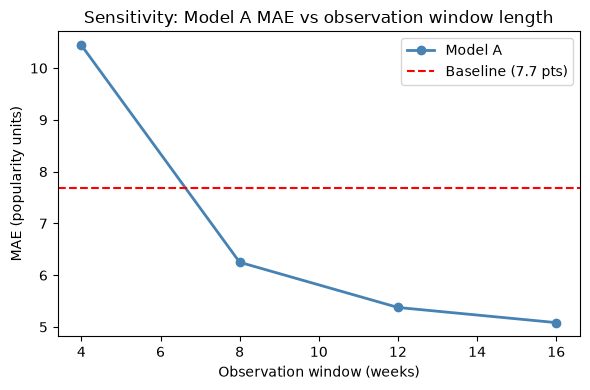

  Window  4 wks -> MAE = 10.44 pts
  Window  8 wks -> MAE = 6.25 pts
  Window 12 wks -> MAE = 5.38 pts
  Window 16 wks -> MAE = 5.08 pts


In [10]:
# re-run walk-forward CV for window lengths 4/8/12/16 weeks
trends = pd.read_csv(DATA_DIR / 'trends_synthetic.csv', parse_dates=['date'])
reviews = pd.read_csv(DATA_DIR / 'reviews_synthetic.csv')
peak_ground_truth = pd.read_csv(RESULTS_DIR / 'peak_ground_truth.csv')

def build_features(window):
    rows = []
    for _, row in peak_ground_truth.iterrows():
        style, year = row['style'], int(row['year'])
        peak_val    = float(row['actual_peak_value'])
        ys = trends.loc[trends['year'] == year, style].values[:window].astype(float)
        t  = np.arange(window, dtype=float)
        sl, _    = np.polyfit(t, ys, 1)
        a2, _, _ = np.polyfit(t, ys, 2)
        rows.append([float(np.mean(ys)), float(sl), float(a2),
                      float(np.max(ys) - np.min(ys)), int(np.argmax(ys)),
                      style, year, peak_val])
    cols = TS_COLS + ['style', 'year', TARGET]
    return pd.DataFrame(rows, columns=cols).sort_values(['year', 'style']).reset_index(drop=True)

def wf_mae_a(df_f):
    n_years = int(df_f['year'].nunique())
    preds, actuals = [], []
    for ty in range(2, n_years):
        tr = df_f[df_f['year'] < ty];  te = df_f[df_f['year'] == ty]
        ytr = tr[TARGET].values.astype(float)
        pipe = make_pipe(TS_COLS)
        pipe.fit(tr[['style'] + TS_COLS], ytr)
        preds.extend(pipe.predict(te[['style'] + TS_COLS]))
        actuals.extend(te[TARGET].values.astype(float))
    return mae(actuals, preds)

windows = [4, 8, 12, 16]
maes_w  = [wf_mae_a(build_features(w)) for w in windows]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(windows, maes_w, marker='o', linewidth=2, color='steelblue', label='Model A')
ax.axhline(mae_base, color='red', linestyle='--', label=f'Baseline ({mae_base:.1f} pts)')
ax.set_xlabel('Observation window (weeks)')
ax.set_ylabel('MAE (popularity units)')
ax.set_title('Sensitivity: Model A MAE vs observation window length')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_sensitivity.png', dpi=100)
plt.show()
for w, m in zip(windows, maes_w):
    print(f'  Window {w:2d} wks -> MAE = {m:.2f} pts')

## Sensitivity - how much early data is enough?

The sensitivity analysis answers: How many weeks of early data are needed? 

- 4 weeks: MAE is higher which is too little information.
- 8 weeks: a good starting point. The model sees enough early behaviour.
- 12–16 weeks: slightly better, but the decision is delayed by 1–2 months.

In a practical context, 8 weeks appears to be the right pragmatic trade-off.

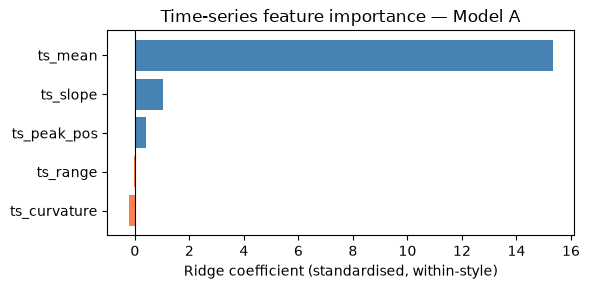

     feature  coefficient
ts_curvature    -0.228817
    ts_range    -0.042601
 ts_peak_pos     0.399628
    ts_slope     1.050763
     ts_mean    15.330546


In [11]:
# Feature importance: RidgeCV coefficients for numerical features (style OHE omitted)
features = pd.read_csv(RESULTS_DIR / 'features.csv')

final_pipe = make_pipe(TS_COLS)
final_pipe.fit(features[['style'] + TS_COLS],
               features[TARGET].values.astype(float))

# Coefficients: first 8 are OHE (one per style), then TS_COLS
all_coefs = final_pipe.named_steps['ridge'].coef_
n_styles  = len(features['style'].unique())
ts_coefs  = all_coefs[n_styles:]   # the numerical feature coefficients

coefficient = pd.DataFrame({'feature': TS_COLS, 'coefficient': ts_coefs})
coefficient = coefficient.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(6, 3))
bar_colors = ['steelblue' if c >= 0 else 'coral' for c in coefficient['coefficient']]
ax.barh(coefficient['feature'], coefficient['coefficient'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ridge coefficient (standardised, within-style)')
ax.set_title('Time-series feature importance — Model A')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_importance.png', dpi=100)
plt.show()
print(coefficient[['feature', 'coefficient']].to_string(index=False))